In [2]:
import numpy as np  # Lenear Algebra
import pandas as pd  # Data processing
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('E:/Dataset/Social_Network_Ads.csv')

In [6]:
df = df.iloc[:, 2:]

In [8]:
df.sample(5)

,Age,EstimatedSalary,Purchased
206,55,130000,1
245,51,146000,1
104,19,21000,0
340,53,104000,1
125,39,61000,0


### Splitting dataset

In [9]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(df.drop('Purchased', axis=1), df['Purchased'], test_size=0.3, random_state=2)

In [22]:
print("Train data shape-",x_train.shape)
print("Test data shape-",x_test.shape)

Train data shape- (280, 2)
Test data shape- (120, 2)


### Data Preprocessing (Standard Scaler)

In [36]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Fit the scaler to the train set, it will learn the parameters
scaler.fit(x_train)

# Transform train, and test sets
x_train_scaled = scaler.transform(x_train)  # Array
x_test_scaled = scaler.transform(x_test)

In [37]:
scaler.mean_

array([3.77642857e+01, 6.99000000e+04])

In [39]:
x_train_scaled = pd.DataFrame(x_train_scaled, columns=x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled, columns=x_test.columns)  # Now pandas DataFrame

In [42]:
np.round(x_train_scaled.describe())

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-2.0,-2.0
25%,-1.0,-1.0
50%,-0.0,0.0
75%,1.0,1.0
max,2.0,2.0


In [43]:
np.round(x_test_scaled.describe())

,Age,EstimatedSalary
count,120.0,120.0
mean,-0.0,-0.0
std,1.0,1.0
min,-2.0,-2.0
25%,-1.0,-1.0
50%,-0.0,-0.0
75%,1.0,1.0
max,2.0,2.0


### Effect of scaling

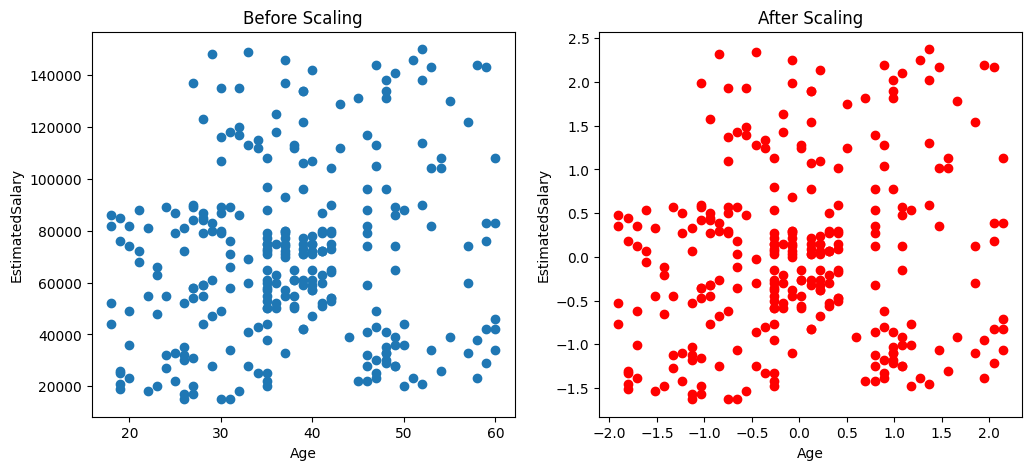

In [51]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))
ax1.scatter(x=x_train['Age'], y=x_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax1.set_xlabel("Age")
ax1.set_ylabel("EstimatedSalary")

ax2.scatter(x=x_train_scaled['Age'], y=x_train_scaled['EstimatedSalary'], color='red')
ax2.set_title("After Scaling")
ax2.set_xlabel("Age")
ax2.set_ylabel("EstimatedSalary")
plt.show()

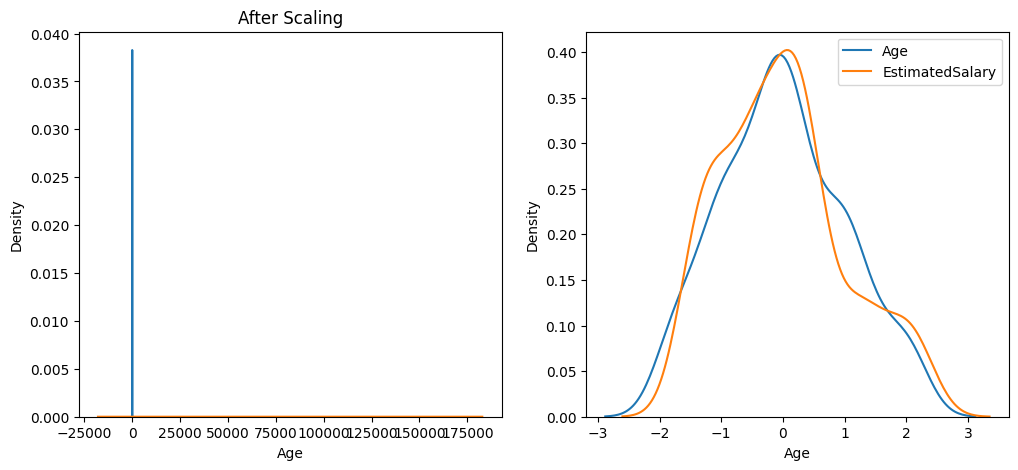

In [62]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

# Before Scaling
sns.kdeplot(x_train['Age'], ax=ax1, label='Age')
sns.kdeplot(x_train['EstimatedSalary'], ax=ax1, label='EstimatedSalary')
ax1.set_title("Before Scaling")

# After Scaling
sns.kdeplot(x_train_scaled['Age'], ax=ax2, label="Age")
sns.kdeplot(x_train_scaled['EstimatedSalary'], ax=ax2, label='EstimatedSalary')
ax1.set_title("After Scaling")

plt.legend()
plt.show()

### Comparison of Distribution

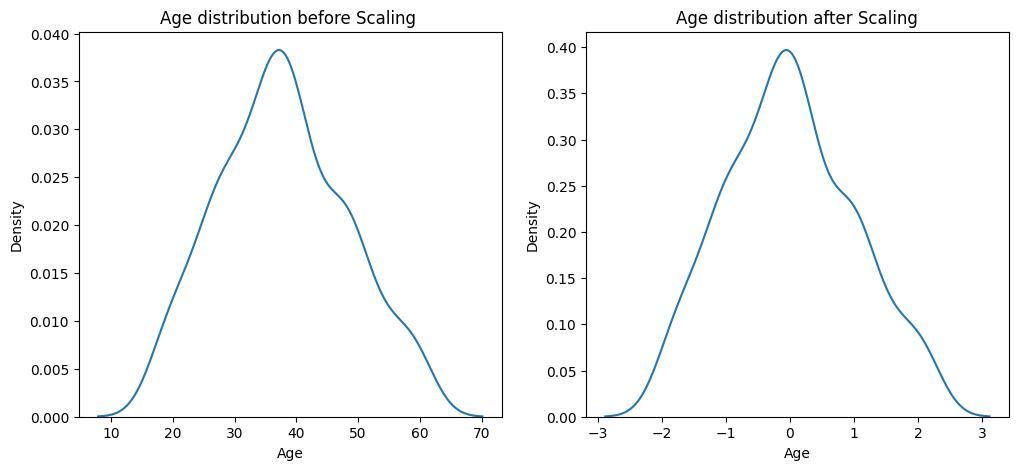

In [64]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

sns.kdeplot(x_train['Age'], ax=ax1)
ax1.set_title("Age distribution before Scaling ")

sns.kdeplot(x_train_scaled['Age'], ax=ax2)
ax2.set_title("Age distribution after Scaling")
plt.show()

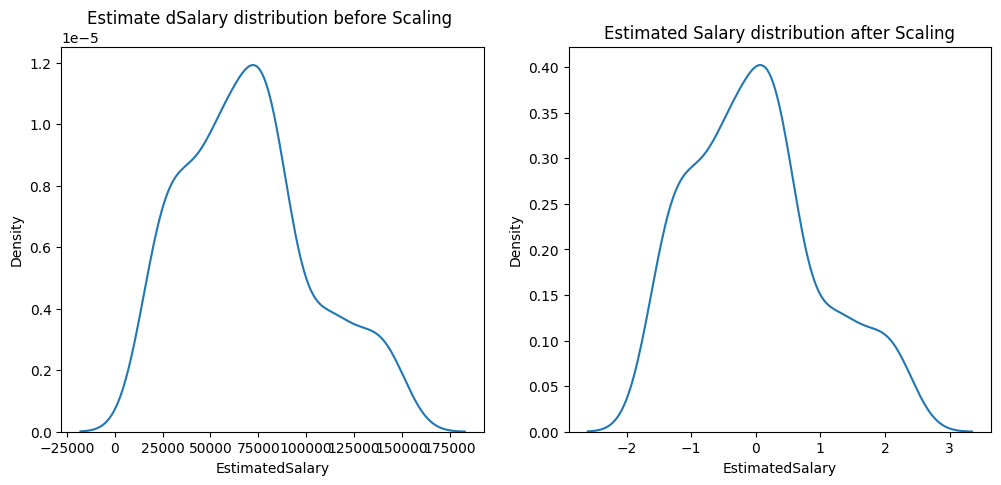

In [65]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

sns.kdeplot(x_train['EstimatedSalary'], ax=ax1)
ax1.set_title("Estimate dSalary distribution before Scaling ")

sns.kdeplot(x_train_scaled['EstimatedSalary'], ax=ax2)
ax2.set_title("Estimated Salary distribution after Scaling")
plt.show()

### Why scaling is important?

#### Logistic Regression eg-

In [66]:
from sklearn.linear_model import LogisticRegression

In [67]:
lr = LogisticRegression()
lr_scaled = LogisticRegression()

In [75]:
lr.fit(x_train, y_train)
lr_scaled.fit(x_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [76]:
y_pred = lr.predict(x_test)
y_pred_scaled = lr_scaled.predict(x_test_scaled)

In [77]:
from sklearn.metrics import accuracy_score

In [78]:
print("Actual :", accuracy_score(y_test, y_pred))
print("Scaled :", accuracy_score(y_test, y_pred_scaled))

Actual : 0.8416666666666667
Scaled : 0.8416666666666667


#### Decision Tree Classifier eg-

In [81]:
from sklearn.tree import DecisionTreeClassifier

In [82]:
dt = DecisionTreeClassifier()
dt_scaled = DecisionTreeClassifier()

In [83]:
dt.fit(x_train, y_train)
dt_scaled.fit(x_train_scaled, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [84]:
y_pred = dt.predict(x_test)
y_pred_scaled = dt_scaled.predict(x_test_scaled)

In [85]:
print("Actual :", accuracy_score(y_test, y_pred))
print("Scaled :", accuracy_score(y_test, y_pred_scaled))

Actual : 0.875
Scaled : 0.8833333333333333
